In [38]:
import sagemaker
from sagemaker import get_execution_role
import boto3
import os
from sagemaker.session import Session
from sagemaker.feature_store.feature_group import FeatureGroup  
from sagemaker import image_uris
from sagemaker.estimator import Estimator
from sagemaker.inputs import TrainingInput
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
from sagemaker.transformer import Transformer

bucket = sagemaker.Session().default_bucket()
print(bucket)
prefix = 'sbml/churnModel'

# Define IAM role
role = get_execution_role()

sagemaker-us-east-2-700633996771


In [39]:
#import stuff we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

In [3]:
region = boto3.Session().region_name
boto_session = boto3.Session(region_name=region)

sagemaker_client = boto_session.client(service_name='sagemaker', region_name=region)
featurestore_runtime = boto_session.client(service_name='sagemaker-featurestore-runtime', region_name=region)

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime
)

feature_group_name = "FG-store-data-6e1326c1"
feature_group = FeatureGroup(name=feature_group_name, sagemaker_session=feature_store_session)


In [4]:
# Build SQL query to features group
fs_query = feature_group.athena_query()
fs_table = fs_query.table_name
query_string = 'SELECT * FROM "'+fs_table+'"'
print('Running ' + query_string)

Running SELECT * FROM "fg_store_data_6e1326c1_1763961440"


In [18]:
# Run query.
fs_query.run(query_string=query_string, output_location='s3://'+bucket+'/'+prefix+'/fs_query_results/')
fs_query.wait()
churn_df = fs_query.as_dataframe() #pandas

INFO:sagemaker:Query 4537a99f-29f8-4fcb-b3a0-9f26d0f93f4a is being executed.
INFO:sagemaker:Query 4537a99f-29f8-4fcb-b3a0-9f26d0f93f4a successfully executed.


In [6]:
churn_df

,id,custid,retained,created,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,...,favday_sunday,firstorder_year,firstorder_day_of_year,lastorder_year,lastorder_day_of_year,order_lifetime_days,days_since_lastorder,write_time,api_invocation_time,is_deleted
0,11140,8XPRYA,1,1.262822e+09,18,0.000000,0.000000,112.94,0.357143,0,...,0.0,2010,194,2010,208,14,5598,2025-11-24 05:27:44.844,2025-11-24 05:22:47.000,False
1,3436,VMETZG,1,1.246320e+09,54,1.851852,1.851852,72.07,0.008627,0,...,0.0,2010,32,2013,327,1391,4383,2025-11-24 05:27:49.625,2025-11-24 05:22:39.000,False
2,1624,4322N3,1,1.262909e+09,45,2.222222,2.222222,96.51,0.000000,0,...,0.0,2010,7,2010,7,0,5799,2025-11-24 05:27:40.563,2025-11-24 05:22:53.000,False
3,9885,SK9XGQ,1,1.244160e+09,16,0.000000,0.000000,40.44,0.375000,1,...,0.0,2009,167,2009,175,8,5996,2025-11-24 05:27:38.476,2025-11-24 05:22:49.000,False
4,3160,JETX2N,1,1.223251e+09,46,8.695652,0.000000,101.46,0.008590,1,...,0.0,2009,138,2013,74,1397,4636,2025-11-24 05:27:41.691,2025-11-24 05:22:41.000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30753,29048,S9VL7J,1,1.507853e+09,39,25.641026,25.641026,51.17,0.000000,1,...,0.0,2017,285,2017,285,0,2964,2025-11-24 05:27:38.614,2025-11-24 05:22:50.000,False
30754,30015,HJFLZY,1,1.511741e+09,31,58.064516,16.129032,91.37,0.192308,1,...,0.0,2017,330,2017,356,26,2893,2025-11-24 05:27:48.657,2025-11-24 05:22:47.000,False
30755,30014,VLWLN8,1,1.511741e+09,30,0.000000,0.000000,45.01,0.000000,1,...,0.0,2017,330,2017,330,0,2919,2025-11-24 05:27:48.657,2025-11-24 05:22:56.000,False
30756,30085,MU3HQ8,1,1.511568e+09,6,50.000000,16.666667,40.25,0.000000,1,...,0.0,2017,336,2017,336,0,2913,2025-11-24 05:27:37.728,2025-11-24 05:22:48.000,False


In [30]:
#EDA is already done in the Canvas, imported into the Feature Store.

#But we do need to remove non-numeric columns
cols_to_drop = ['custid', 'city', 'favday', 'created', 'write_time', 'api_invocation_time', 'is_deleted']

# Create clean dataframe with only numeric features
numeric_cols = [col for col in churn_df.columns if col not in cols_to_drop]
churn_clean = churn_df[numeric_cols].copy()

# Reorder columns since XGBoost needs the target as the first column.
cols = churn_clean.columns.tolist()
cols.remove('retained')
cols = ['retained'] + cols
churn_clean = churn_clean[cols]

print(f"\nFinal columns: {churn_clean.columns.tolist()}")
print(f"Shape: {churn_clean.shape}")


Final columns: ['retained', 'id', 'esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq', 'paperless', 'refill', 'doorstep', 'city_bom', 'city_maa', 'city_del', 'city_blr', 'favday_tuesday', 'favday_monday', 'favday_thursday', 'favday_friday', 'favday_wednesday', 'favday_saturday', 'favday_sunday', 'firstorder_year', 'firstorder_day_of_year', 'lastorder_year', 'lastorder_day_of_year', 'order_lifetime_days', 'days_since_lastorder']
Shape: (30758, 27)


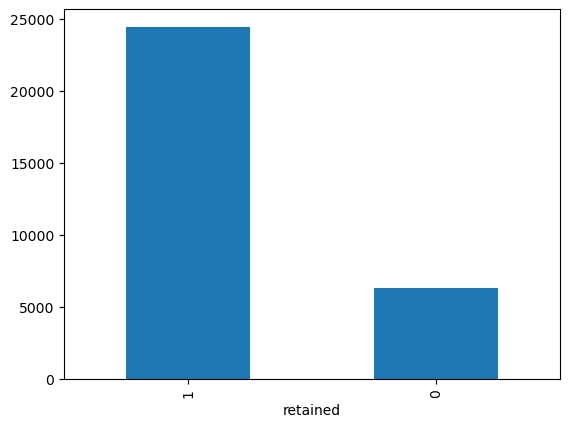

In [31]:
#Let's check to see how imbalanced the retain column is. Prob could have done this in the FLOW

churn_clean.retained.value_counts().plot(kind='bar')
plt.show()

In [51]:
# Split the data
train_df, test_df = train_test_split(
    churn_clean, 
    test_size=0.25, 
    random_state=67, 
    stratify=churn_df['retained']
)
train_df.head()


,retained,id,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,refill,doorstep,...,favday_friday,favday_wednesday,favday_saturday,favday_sunday,firstorder_year,firstorder_day_of_year,lastorder_year,lastorder_day_of_year,order_lifetime_days,days_since_lastorder
20383,1,20671,28,3.571429,0.000,55.29,0.000000,1,0,0,...,0.0,0.0,0.0,0.0,2013,320,2013,320,0,4390
26703,1,26516,32,6.250000,3.125,36.00,0.003810,0,0,0,...,0.0,0.0,0.0,1.0,2016,222,2018,16,525,2868
8799,1,936,45,2.222222,0.000,52.03,0.000000,0,0,0,...,0.0,0.0,0.0,0.0,2013,27,2013,27,0,4683
25272,1,23623,10,90.000000,20.000,99.16,0.000000,1,0,0,...,1.0,0.0,0.0,0.0,2014,1,2014,1,0,4344
6312,1,2481,45,13.333333,0.000,100.69,0.019417,0,0,0,...,0.0,0.0,0.0,0.0,2013,119,2013,222,103,4488


In [58]:
#We'll need this later, test data without the target column

predict_df = test_df.iloc[:, 1:]  # Skip first/target column
predict_df.head()

,id,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,refill,doorstep,city_bom,...,favday_friday,favday_wednesday,favday_saturday,favday_sunday,firstorder_year,firstorder_day_of_year,lastorder_year,lastorder_day_of_year,order_lifetime_days,days_since_lastorder
17804,20493,27,22.222222,14.814815,29.30,0.000000,1,0,0,0.0,...,0.0,1.0,0.0,0.0,2014,13,2014,13,0,4332
12986,19641,29,10.344828,6.896552,93.40,0.068966,1,0,0,0.0,...,0.0,0.0,0.0,0.0,2013,310,2013,339,29,4371
10102,1692,43,6.976744,2.325581,98.12,0.000000,0,0,0,1.0,...,0.0,0.0,0.0,0.0,2013,165,2013,165,0,4545
40,9875,0,0.000000,0.000000,27.11,0.119497,0,0,0,0.0,...,1.0,0.0,0.0,0.0,2010,7,2010,166,159,5640
19024,15016,42,16.666667,2.380952,48.86,0.076923,1,0,0,1.0,...,0.0,0.0,0.0,0.0,2013,275,2013,301,26,4409


In [63]:
# Save to CSV (no headers, no index, already removed non-numeric)
train_df.to_csv('train.csv', header=False, index=False)
train_df.to_csv('test.csv', header=False, index=False)
predict_df.to_csv('predict.csv', header=False, index=False)

train_s3_path = f'{prefix}/train/train.csv'
test_s3_path = f'{prefix}/test/test.csv'
predict_s3_path = f'{prefix}/predict/predict.csv'

# Upload to S3
boto3.Session().resource('s3').Bucket(bucket).Object(train_s3_path).upload_file('train.csv')
boto3.Session().resource('s3').Bucket(bucket).Object(test_s3_path).upload_file('test.csv')
boto3.Session().resource('s3').Bucket(bucket).Object(predict_s3_path).upload_file('predict.csv')

print(f"Training data uploaded to: s3://{bucket}/{prefix}/train/train.csv")
print(f"Test data uploaded to: s3://{bucket}/{prefix}/test/test.csv")
print(f"Predict data uploaded to: s3://{bucket}/{prefix}/predict/predict.csv")

Training data uploaded to: s3://sagemaker-us-east-2-700633996771/sbml/churnModel/train/train.csv
Test data uploaded to: s3://sagemaker-us-east-2-700633996771/sbml/churnModel/test/test.csv
Predict data uploaded to: s3://sagemaker-us-east-2-700633996771/sbml/churnModel/predict/predict.csv


In [35]:
# Get the XGBoost container. Stolen from LinkedIn learning Lesson examples.
container = image_uris.retrieve(region=boto3.Session().region_name, 
                                 framework='xgboost', 
                                 version='latest')

print(bucket)
print(train_s3_path)
print(test_s3_path)
print(predict_s3_path)

# Create XGBoost estimator
xgb = Estimator(
    container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://{bucket}/{prefix}/output',
    sagemaker_session=sagemaker.Session()
)

# Set hyperparameters
xgb.set_hyperparameters(
    objective='binary:logistic',  # Binary classification
    num_round=100,                # Number of boosting rounds
    max_depth=5,                  # Maximum tree depth
    eta=0.2,                      # Learning rate
    subsample=0.8,                # Subsample ratio
    eval_metric='auc'             # Evaluation metric (AUC)
)

# Train the model
xgb.fit({
    'train': TrainingInput(f's3://{bucket}/{train_s3_path}', content_type='text/csv'),
    'validation': TrainingInput(f's3://{bucket}/{test_s3_path}', content_type='text/csv')
})

print("Training complete!")

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: xgboost-2025-12-06-15-52-26-133


sagemaker-us-east-2-700633996771
sbml/churnModel/train/train.csv
sbml/churnModel/test/test.csv
2025-12-06 15:52:26 Starting - Starting the training job...
2025-12-06 15:52:45 Starting - Preparing the instances for training...
2025-12-06 15:53:24 Downloading - Downloading the training image......
2025-12-06 15:54:25 Training - Training image download completed. Training in progress.
2025-12-06 15:54:25 Uploading - Uploading generated training modelArguments: train
[2025-12-06:15:54:17:INFO] Running standalone xgboost training.
[2025-12-06:15:54:17:INFO] File size need to be processed in the node: 3.36mb. Available memory size in the node: 8222.27mb
[2025-12-06:15:54:17:INFO] Determined delimiter of CSV input is ','
[15:54:17] S3DistributionType set as FullyReplicated
[15:54:17] 23068x26 matrix with 599768 entries loaded from /opt/ml/input/data/train?format=csv&label_column=0&delimiter=,
[2025-12-06:15:54:17:INFO] Determined delimiter of CSV input is ','
[15:54:17] S3DistributionType set

In [64]:
# It appears that you need to use a Batch Transform Job OR Deploy this thing as XGBoost
# running here in SageMaker does not have a predict method like scikit Learn.

# It is not clear to me which is preferred, but Batch Transform feels better
# since we are deploying through SageMaker in the next steps via ClickOps methods, not code.
# and it looks like xbg has a transformer built in too.

transformer = xgb.transformer(
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://{bucket}/{prefix}/batch-predictions/',
    accept='text/csv',
    assemble_with='Line'
)

transformer.transform(
    f's3://{bucket}/{predict_s3_path}',
    content_type='text/csv',
    split_type='Line',
    wait=True
)

print("Predictions complete!")

INFO:sagemaker:Creating model with name: xgboost-2025-12-06-16-36-43-702
INFO:sagemaker:Creating transform job with name: xgboost-2025-12-06-16-36-44-536


........................
Arguments: serve
[2025-12-06 16:40:46 +0000] [1] [INFO] Starting gunicorn 19.9.0
[2025-12-06 16:40:46 +0000] [1] [INFO] Listening at: http://0.0.0.0:8080 (1)
[2025-12-06 16:40:46 +0000] [1] [INFO] Using worker: gevent
[2025-12-06 16:40:46 +0000] [21] [INFO] Booting worker with pid: 21
[2025-12-06 16:40:46 +0000] [22] [INFO] Booting worker with pid: 22
[2025-12-06 16:40:46 +0000] [23] [INFO] Booting worker with pid: 23
[2025-12-06 16:40:47 +0000] [24] [INFO] Booting worker with pid: 24
/opt/amazon/lib/python3.7/site-packages/gunicorn/workers/ggevent.py:65: MonkeyPatchWarning: Monkey-patching ssl after ssl has already been imported may lead to errors, including RecursionError on Python 3.6. It may also silently lead to incorrect behaviour on Python 3.7. Please monkey-patch earlier. See https://github.com/gevent/gevent/issues/1016. Modules that had direct imports (NOT patched): ['urllib3.util.ssl_ (/opt/amazon/lib/python3.7/site-packages/urllib3/util/ssl_.py)', 'u


AUC ROC Score: 0.9882



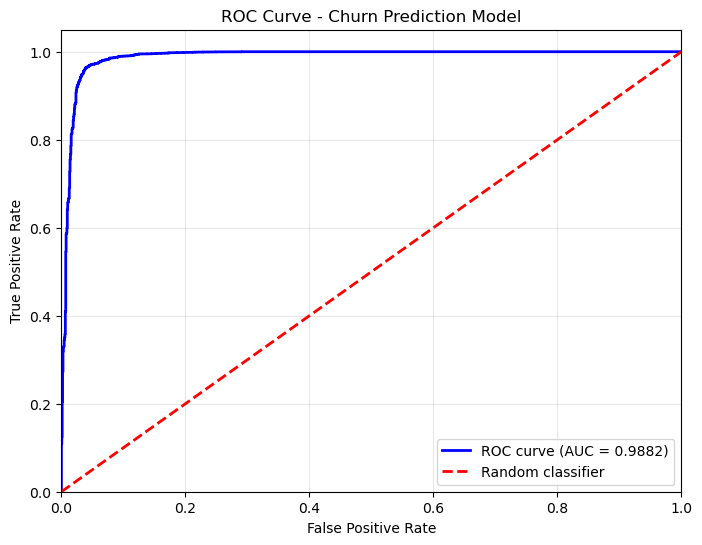

In [67]:
# Go get the predictions output file
predictions_key = f'{prefix}/batch-predictions/predict.csv.out'
local_predictions_file = 'predictions.csv'

boto3.Session().resource('s3').Bucket(bucket).Object(predictions_key).download_file(local_predictions_file)
y_pred_proba = pd.read_csv(local_predictions_file, header=None).values.flatten()

# Get true labels from test set
y_test_true = test_df.iloc[:, 0].values

# Calculate AUC ROC
auc_score = roc_auc_score(y_test_true, y_pred_proba)
print(f"\n{'='*50}")
print(f"AUC ROC Score: {auc_score:.4f}")
print(f"{'='*50}\n")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_true, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Well. That looks pretty darn good. Good work on my EDA. The tooling in the DataWrangler made it a smidge easier to figure out what to do thanks to their analysis tool but  the issues I had getting that outputed flow and notebook to run made it all not worth it, from a time perspective. Bummer.

Honestly, this assignment stunk, entirely due to the AWS portion. I get why we did it, the actual ML work was fairly easy but adapting to a new tool set that was much harder to use than Canvas or Jupyter Notebook via PyCharm just made everything much harder. Esp since at work I will have to use Google products, like Vertex AI.

Not a big deal but as feedback, know that this assignment took me about 8 hours and 6.5 of them were dealing with AWS problems. Would have done this in 90 minutes or less in vanilla Jupyter.

The AWS Tools ARE good for collaboration and deployment and MLOps, I get it. Probably worthwhile to see.

Yay. Done.